In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))


In [8]:
import anndata as ad
import torch
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd

from utils import get_scgpt_model, binning
from premium_datasets import scDataset, bulkDataset, predictionDataset, collate_fn
from adapters import scGPTClassifier, MLPClassifier, train_epoch, eval_epoch, load_trained_model


In [3]:
adata_path = 'data_new/train.h5ad'
adata = ad.read_h5ad(adata_path)

data_path = '../data/0_data_for_mlp/TCGA-BRCA.star_tpm.csv'
data = pd.read_csv(data_path)


## ENERGY AND JACCARD

Loading data...
Shared genes: 19,511  |  bulk: 20,260  |  sc: 61,497
  n= 1  frac@1000=0.771  jaccard@1000=0.174
  n= 2  frac@1000=0.683  jaccard@1000=0.207
  n= 5  frac@1000=0.552  jaccard@1000=0.245
  n=10  frac@1000=0.499  jaccard@1000=0.272
  n=50  frac@1000=0.442  jaccard@1000=0.324


/tmp/ipykernel_2458661/2029736917.py:110: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap        = cm.get_cmap('Blues')


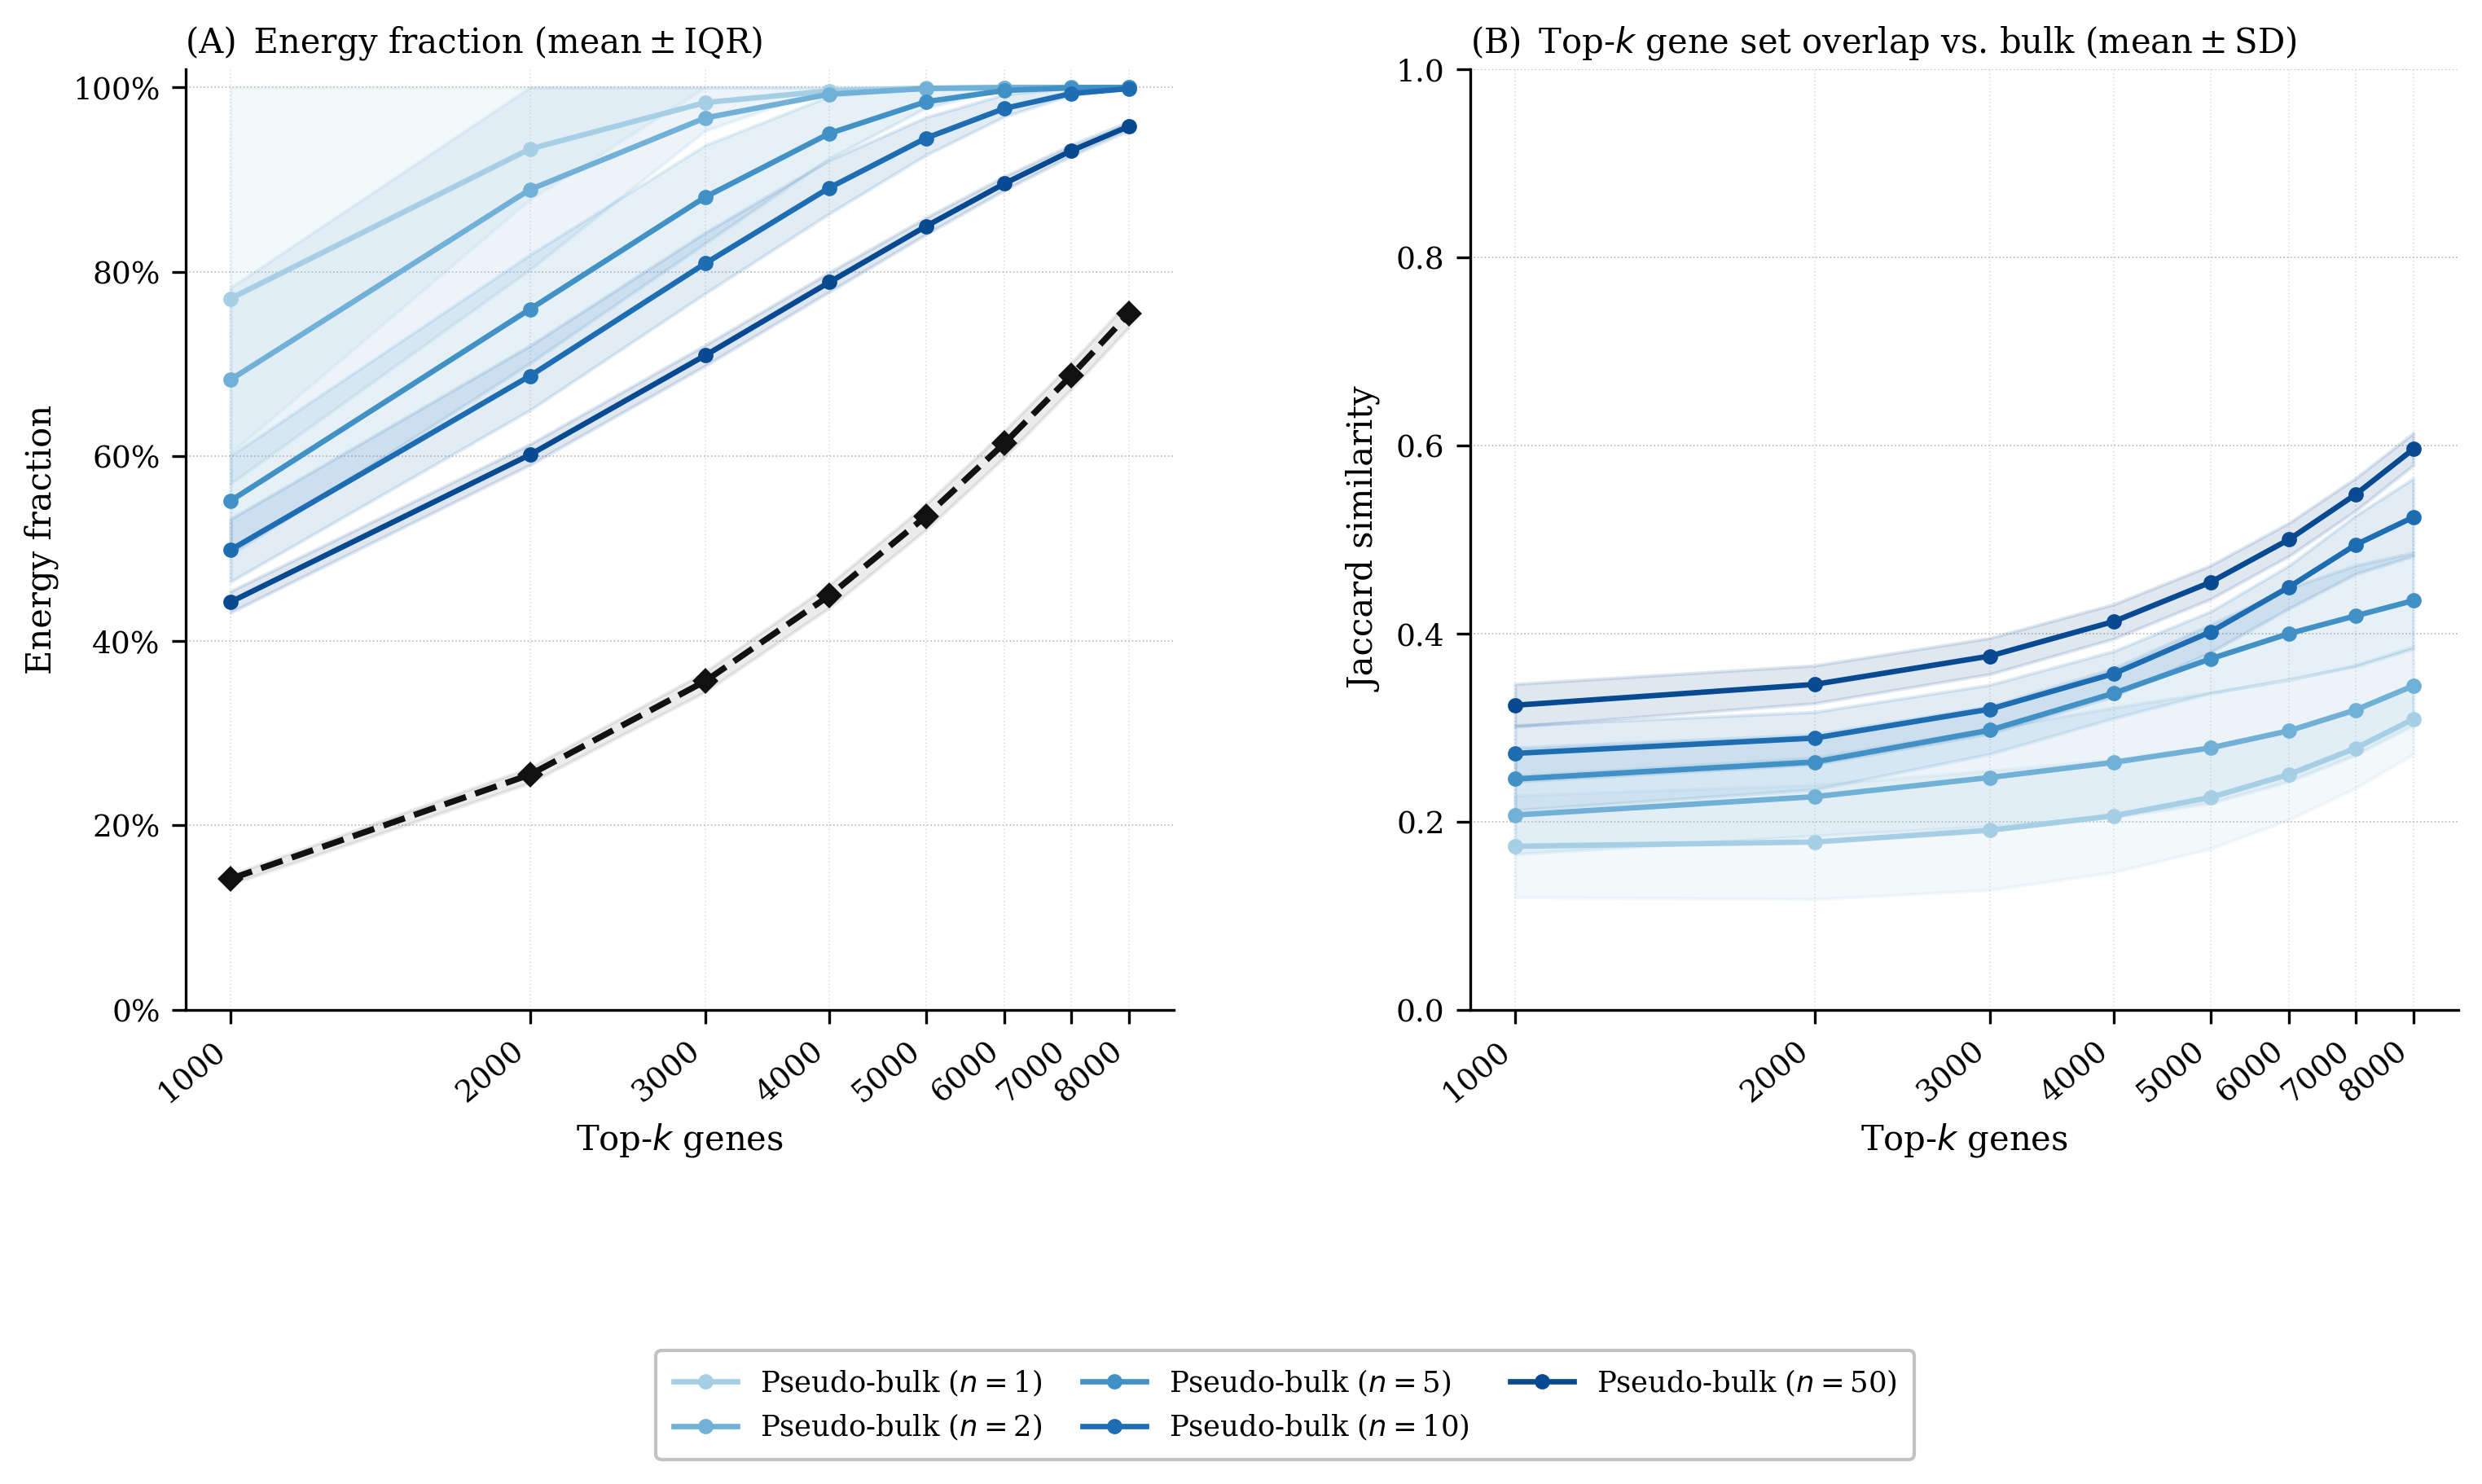

In [16]:
import anndata as ad
import pandas as pd
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.cm as cm

# ─── CONFIG ───────────────────────────────────────────────────────────────────
TOPK_VALUES    = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000]
PSEUDO_N_CELLS = [1, 2, 5, 10, 50]
N_SAMPLE       = 500
SEED           = 42

# ─── LOAD ─────────────────────────────────────────────────────────────────────
print("Loading data...")
adata = ad.read_h5ad('data_new/train.h5ad')
bulk  = pd.read_csv('../data/0_data_for_mlp/TCGA-BRCA.star_tpm.csv', index_col=0)

# ─── GENE MATCHING ────────────────────────────────────────────────────────────
sc_genes   = adata.var['feature_name_mapped'].values
bulk_genes = bulk.columns.tolist()
shared     = list(set(sc_genes) & set(bulk_genes))
print(f"Shared genes: {len(shared):,}  |  bulk: {len(bulk_genes):,}  |  sc: {len(sc_genes):,}")

sc_idx = [np.where(sc_genes == g)[0][0] for g in shared]
X_sc   = adata.X[:, sc_idx]
if sp.issparse(X_sc):
    X_sc = X_sc.toarray().astype(np.float32)

X_bulk = bulk[shared].values.astype(np.float32)

# ─── HELPERS ──────────────────────────────────────────────────────────────────
def topk_sum(matrix, k):
    """Sum of top-k values per row (absolute energy)."""
    k = min(k, matrix.shape[1])
    return np.partition(matrix, -k, axis=1)[:, -k:].sum(axis=1)

def energy_fraction(matrix, k):
    """top-k sum / total sum per row."""
    total = matrix.sum(axis=1)
    return np.where(total > 0, topk_sum(matrix, k) / total, np.nan)

def make_pseudo_bulk(X, n_cells, n_sample, rng):
    idx     = rng.choice(len(X), size=(n_sample, n_cells), replace=True)
    weights = rng.dirichlet(np.ones(n_cells), size=n_sample)
    return np.einsum('ij,ijk->ik', weights, X[idx])

def stats(arr):
    """mean, std, p25, p75."""
    return (np.nanmean(arr), np.nanstd(arr),
            np.nanpercentile(arr, 25), np.nanpercentile(arr, 75))

# ─── COMPUTE ──────────────────────────────────────────────────────────────────
rng      = np.random.default_rng(SEED)
valid_ks = [k for k in TOPK_VALUES if k <= X_bulk.shape[1]]

def topk_indices(matrix, k):
    k = min(k, matrix.shape[1])
    return np.argpartition(matrix, -k, axis=1)[:, -k:]

def mean_jaccard(idx_a, idx_b, n_pairs=2000, seed=0):
    rng_j = np.random.default_rng(seed)
    ia = rng_j.choice(len(idx_a), n_pairs)
    ib = rng_j.choice(len(idx_b), n_pairs)
    scores = np.array([
        len(set(idx_a[i]) & set(idx_b[j])) / len(set(idx_a[i]) | set(idx_b[j]))
        for i, j in zip(ia, ib)
    ])
    return scores.mean(), scores.std(), np.percentile(scores, 25), np.percentile(scores, 75)

# precompute bulk stats and top-k indices
bulk_frac = {k: stats(energy_fraction(X_bulk, k)) for k in valid_ks}
bulk_topk = {k: topk_indices(X_bulk, k)           for k in valid_ks}

# pseudo-bulk: energy fraction + jaccard vs bulk
pseudo_frac    = {}
pseudo_jaccard = {}
for n in PSEUDO_N_CELLS:
    X_ps = make_pseudo_bulk(X_sc, n, N_SAMPLE, rng)
    pseudo_frac[n]    = {k: stats(energy_fraction(X_ps, k))          for k in valid_ks}
    pseudo_jaccard[n] = {k: mean_jaccard(topk_indices(X_ps, k),
                                         bulk_topk[k])                for k in valid_ks}
    k_ref = min(1000, valid_ks[-1])
    print(f"  n={n:2d}  frac@{k_ref}={pseudo_frac[n][k_ref][0]:.3f}"
          f"  jaccard@{k_ref}={pseudo_jaccard[n][k_ref][0]:.3f}")

# ─── PUBLICATION STYLE ────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['Times New Roman', 'DejaVu Serif'],
    'font.size':         9,
    'axes.labelsize':    10,
    'axes.titlesize':    10,
    'axes.linewidth':    0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size':  4,
    'ytick.major.size':  4,
    'legend.fontsize':   8.5,
    'legend.framealpha': 0.95,
    'legend.edgecolor':  '0.75',
    'figure.dpi':        300,
    'savefig.dpi':       300,
    'pdf.fonttype':      42,
    'ps.fonttype':       42,
})

n_ps        = len(PSEUDO_N_CELLS)
cmap        = cm.get_cmap('Blues')
colors      = [cmap(0.35 + 0.55 * i / (n_ps - 1)) for i in range(n_ps)]
BULK_COLOR  = '#111111'
BULK_MARKER = 'D'
PS_MARKER   = 'o'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), 
                                gridspec_kw={'wspace': 0.3})

# ─── PANEL A: energy fraction (mean ± IQR) ────────────────────────────────────
bm, _, bp25, bp75 = zip(*[bulk_frac[k] for k in valid_ks])
ax1.plot(valid_ks, bm, color=BULK_COLOR, lw=1.8, ls='--',
         marker=BULK_MARKER, ms=4.5, zorder=5, label='Bulk RNA-seq (TCGA-BRCA)')
ax1.fill_between(valid_ks, bp25, bp75, color=BULK_COLOR, alpha=0.08)

for i, n in enumerate(PSEUDO_N_CELLS):
    pm, _, pp25, pp75 = zip(*[pseudo_frac[n][k] for k in valid_ks])
    ax1.plot(valid_ks, pm, color=colors[i], lw=1.6,
             marker=PS_MARKER, ms=3.5, zorder=4,
             label=f'Pseudo-bulk ($n$\u202f=\u202f{n})')
    ax1.fill_between(valid_ks, pp25, pp75, color=colors[i], alpha=0.13)

ax1.set_xscale('log', base=2)
ax1.set_xticks(valid_ks)
ax1.set_xticklabels([str(k) for k in valid_ks], rotation=40, ha='right')
ax1.set_xlabel('Top-$k$ genes')
ax1.set_ylabel('Energy fraction')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
ax1.set_ylim(0, 1.02)
ax1.grid(True, axis='y', lw=0.4, ls=':', color='0.72')
ax1.grid(True, axis='x', lw=0.4, ls=':', color='0.88')
ax1.set_axisbelow(True)
ax1.spines[['top', 'right']].set_visible(False)
ax1.set_title('(A)\u2002Energy fraction (mean\u202f\u00b1\u202fIQR)', pad=5, loc='left')

# ─── PANEL B: Jaccard overlap pseudo-bulk vs bulk ─────────────────────────────
for i, n in enumerate(PSEUDO_N_CELLS):
    jm, jsd, _, _ = zip(*[pseudo_jaccard[n][k] for k in valid_ks])
    jm, jsd = np.array(jm), np.array(jsd)
    ax2.plot(valid_ks, jm, color=colors[i], lw=1.6,
             marker=PS_MARKER, ms=3.5, zorder=4,
             label=f'Pseudo-bulk ($n$\u202f=\u202f{n})')
    ax2.fill_between(valid_ks, jm - jsd, jm + jsd, color=colors[i], alpha=0.13)

ax2.set_xscale('log', base=2)
ax2.set_xticks(valid_ks)
ax2.set_xticklabels([str(k) for k in valid_ks], rotation=40, ha='right')
ax2.set_xlabel('Top-$k$ genes')
ax2.set_ylabel('Jaccard similarity')
ax2.set_ylim(0, 1.0)
ax2.grid(True, axis='y', lw=0.4, ls=':', color='0.72')
ax2.grid(True, axis='x', lw=0.4, ls=':', color='0.88')
ax2.set_axisbelow(True)
ax2.spines[['top', 'right']].set_visible(False)
ax2.set_title('(B)\u2002Top-$k$ gene set overlap vs. bulk (mean\u202f\u00b1\u202fSD)', pad=5, loc='left')

# ─── SHARED LEGEND ────────────────────────────────────────────────────────────
handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels,
           loc='lower center',
           ncol=3,
           bbox_to_anchor=(0.5, -0.27),
           frameon=True,
           handlelength=2.2,
           columnspacing=1.4,
           borderpad=0.6)

plt.show()

## PCA UMAP SUROWE DANE

Loading data...
Shared genes: 19,511
Running PCA...
Running UMAP...


/scratch/2370352/conda/envs/scgpt/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_2458661/502084174.py:89: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap      = cm.get_cmap('Blues')
/tmp/ipykernel_2458661/502084174.py:106: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x[idx], y[idx], c=ps_colors[i], s=6, alpha=0.5,


Saved: pca_umap_analysis.pdf  /  pca_umap_analysis.png


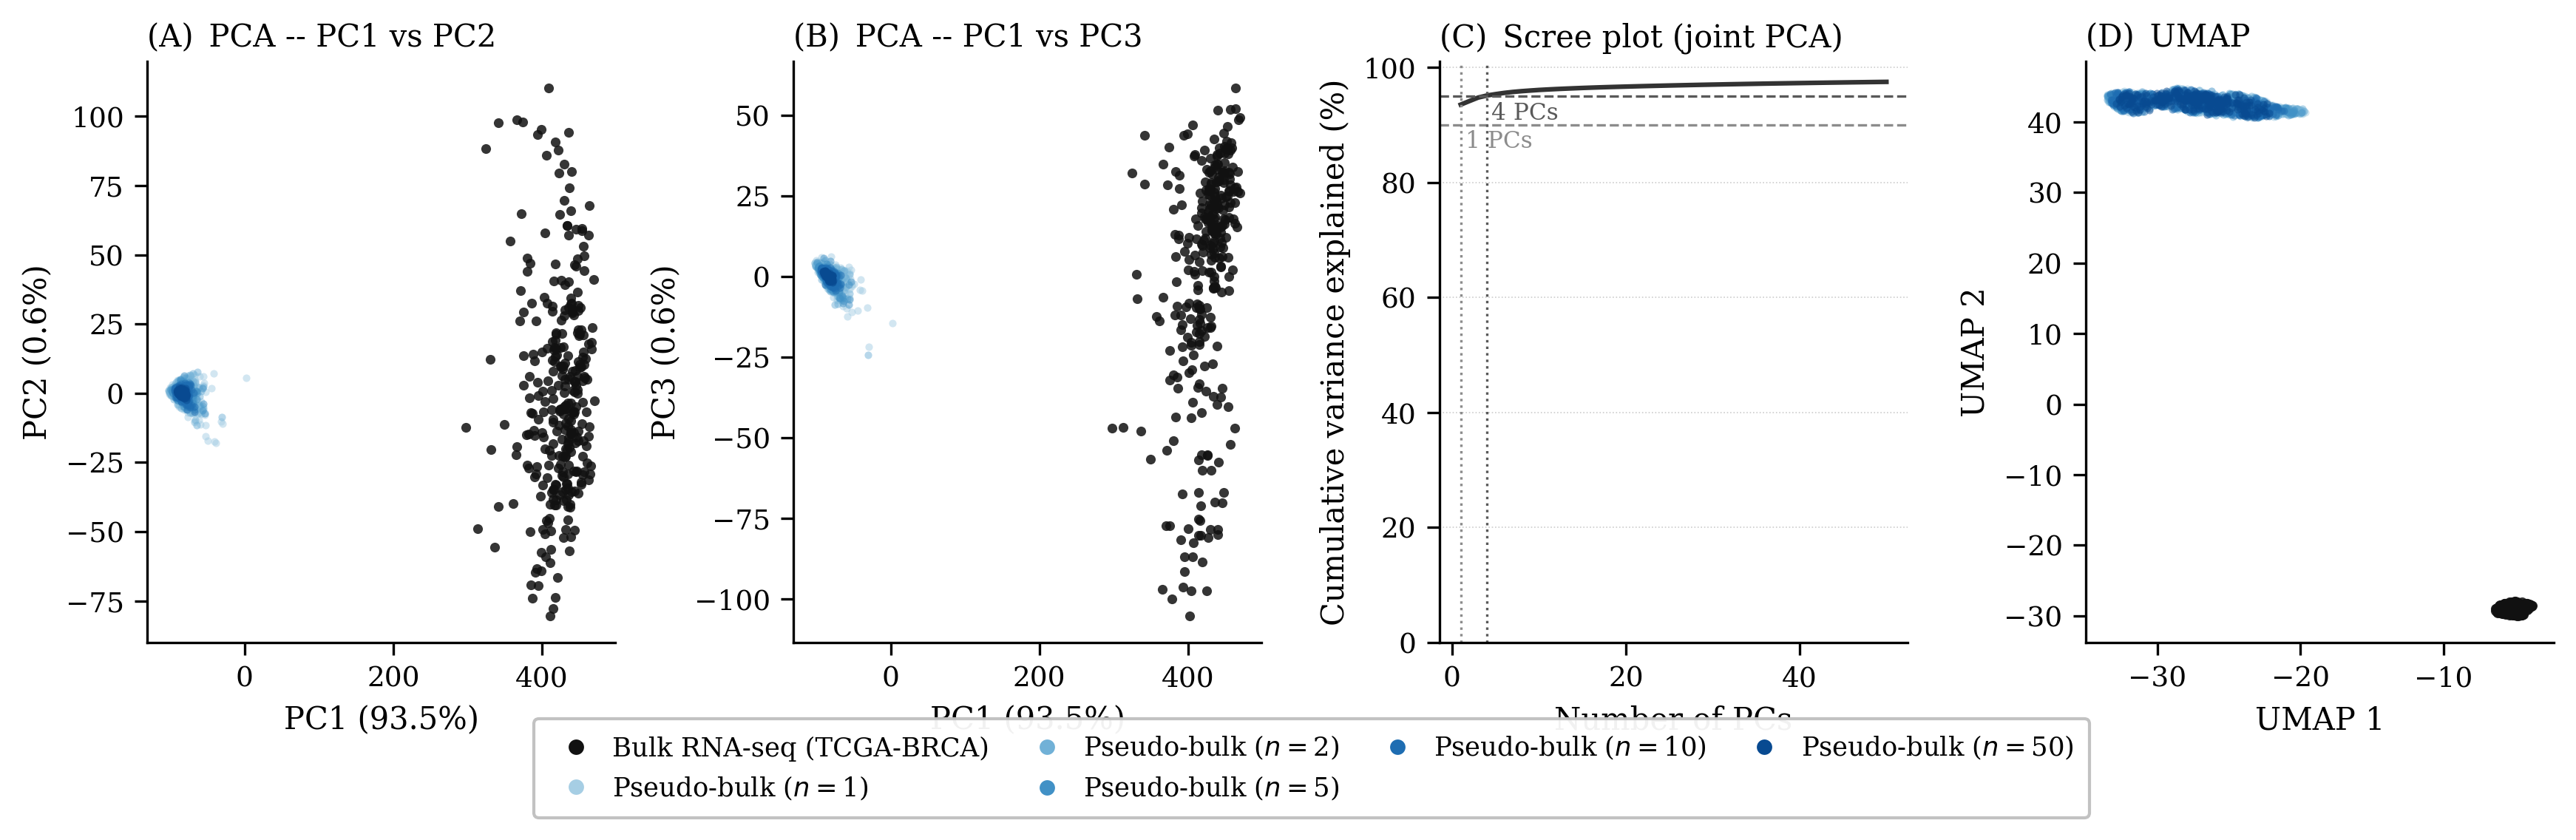


Centroid L2 distances from bulk (PC1-10):
  n= 1  506.248
  n= 2  508.034
  n= 5  507.147
  n=10  508.157
  n=50  508.031


In [20]:
import anndata as ad
import pandas as pd
import numpy as np
import scipy.sparse as sp
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D

try:
    import umap
    HAS_UMAP = True
except ImportError:
    print("umap-learn not found -- skipping UMAP (pip install umap-learn)")
    HAS_UMAP = False

# ---- CONFIG ------------------------------------------------------------------
PSEUDO_N_CELLS = [1, 2, 5, 10, 50]
N_SAMPLE       = 300
N_BULK_SUB     = 300
SEED           = 42

# ---- LOAD --------------------------------------------------------------------
print("Loading data...")
adata = ad.read_h5ad('data_new/train.h5ad')
bulk  = pd.read_csv('../data/0_data_for_mlp/TCGA-BRCA.star_tpm.csv', index_col=0)

# ---- GENE MATCHING -----------------------------------------------------------
sc_genes   = adata.var['feature_name_mapped'].values
bulk_genes = bulk.columns.tolist()
shared     = list(set(sc_genes) & set(bulk_genes))
print(f"Shared genes: {len(shared):,}")

sc_idx = [np.where(sc_genes == g)[0][0] for g in shared]
X_sc   = adata.X[:, sc_idx]
if sp.issparse(X_sc):
    X_sc = X_sc.toarray().astype(np.float32)

X_bulk = bulk[shared].values.astype(np.float32)

# ---- PSEUDO-BULK -------------------------------------------------------------
def make_pseudo_bulk(X, n_cells, n_sample, rng):
    idx     = rng.choice(len(X), size=(n_sample, n_cells), replace=True)
    weights = rng.dirichlet(np.ones(n_cells), size=n_sample)
    return np.einsum('ij,ijk->ik', weights, X[idx])

rng = np.random.default_rng(SEED)
pseudo_matrices = {n: make_pseudo_bulk(X_sc, n, N_SAMPLE, rng) for n in PSEUDO_N_CELLS}

bulk_idx   = rng.choice(len(X_bulk), N_BULK_SUB, replace=False)
X_bulk_sub = X_bulk[bulk_idx]

# ---- COMBINED MATRIX ---------------------------------------------------------
all_X_mat  = np.vstack([X_bulk_sub] + [pseudo_matrices[n] for n in PSEUDO_N_CELLS])
all_labels = (
    ['Bulk'] * N_BULK_SUB +
    [f'Pseudo (n={n})' for n in PSEUDO_N_CELLS for _ in range(N_SAMPLE)]
)

# ---- PCA ---------------------------------------------------------------------
print("Running PCA...")
pca     = PCA(n_components=50, random_state=SEED)
coords  = pca.fit_transform(all_X_mat)
var_exp = pca.explained_variance_ratio_

# ---- UMAP --------------------------------------------------------------------
if HAS_UMAP:
    print("Running UMAP...")
    reducer     = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=30, min_dist=0.3)
    umap_coords = reducer.fit_transform(all_X_mat)

# ---- STYLE -------------------------------------------------------------------
plt.rcParams.update({
    'font.family':    'serif',
    'font.serif':     ['Times New Roman', 'DejaVu Serif'],
    'font.size':      9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'axes.linewidth': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'figure.dpi':     300,
    'savefig.dpi':    300,
    'pdf.fonttype':   42,
    'ps.fonttype':    42,
})

n_ps      = len(PSEUDO_N_CELLS)
cmap      = cm.get_cmap('Blues')
ps_colors = [cmap(0.35 + 0.55 * i / (n_ps - 1)) for i in range(n_ps)]
BULK_COLOR = '#111111'

def group_idx(label):
    return [i for i, l in enumerate(all_labels) if l == label]

idx_b = group_idx('Bulk')

# ---- FIGURE ------------------------------------------------------------------
n_panels = 4 if HAS_UMAP else 3
fig, axes = plt.subplots(1, n_panels, figsize=(3.5 * n_panels, 3.4),
                         gridspec_kw={'wspace': 0.38})

def scatter_all(ax, x, y):
    for i, n in enumerate(PSEUDO_N_CELLS):
        idx = group_idx(f'Pseudo (n={n})')
        ax.scatter(x[idx], y[idx], c=ps_colors[i], s=6, alpha=0.5,
                   linewidths=0, rasterized=True)
    ax.scatter(x[idx_b], y[idx_b], c=BULK_COLOR, s=10, alpha=0.85,
               linewidths=0, rasterized=True, zorder=5)
    ax.spines[['top', 'right']].set_visible(False)

# Panel A: PC1 vs PC2
scatter_all(axes[0], coords[:, 0], coords[:, 1])
axes[0].set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)')
axes[0].set_title('(A)\u2002PCA -- PC1 vs PC2', pad=5, loc='left')

# Panel B: PC1 vs PC3
scatter_all(axes[1], coords[:, 0], coords[:, 2])
axes[1].set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC3 ({var_exp[2]*100:.1f}%)')
axes[1].set_title('(B)\u2002PCA -- PC1 vs PC3', pad=5, loc='left')

# Panel C: cumulative explained variance
ax = axes[2]
cumvar = np.cumsum(var_exp) * 100
ax.plot(range(1, len(cumvar) + 1), cumvar, color='#333333', lw=1.5)
for thresh, col in [(90, '0.55'), (95, '0.35')]:
    cross = int(np.searchsorted(cumvar, thresh))
    ax.axhline(thresh, color=col, lw=0.8, ls='--')
    if cross < len(cumvar):
        ax.axvline(cross + 1, color=col, lw=0.8, ls=':')
        ax.text(cross + 1.5, thresh - 4, f'{cross+1} PCs', fontsize=7.5, color=col)
ax.set_xlabel('Number of PCs')
ax.set_ylabel('Cumulative variance explained (%)')
ax.set_title('(C)\u2002Scree plot (joint PCA)', pad=5, loc='left')
ax.set_ylim(0, 101)
ax.grid(True, axis='y', lw=0.4, ls=':', color='0.8')
ax.spines[['top', 'right']].set_visible(False)

# Panel D: UMAP
if HAS_UMAP:
    scatter_all(axes[3], umap_coords[:, 0], umap_coords[:, 1])
    axes[3].set_xlabel('UMAP 1')
    axes[3].set_ylabel('UMAP 2')
    axes[3].set_title('(D)\u2002UMAP', pad=5, loc='left')

# ---- LEGEND ------------------------------------------------------------------
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=BULK_COLOR,
           markersize=6, label='Bulk RNA-seq (TCGA-BRCA)'),
] + [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=ps_colors[i],
           markersize=6, label=f'Pseudo-bulk ($n$\u202f=\u202f{n})')
    for i, n in enumerate(PSEUDO_N_CELLS)
]
fig.legend(handles=legend_handles, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.14), frameon=True,
           handletextpad=0.4, columnspacing=1.2, borderpad=0.6, fontsize=8.5)

plt.savefig('pca_umap_analysis.pdf', bbox_inches='tight')
plt.savefig('pca_umap_analysis.png', bbox_inches='tight')
print("Saved: pca_umap_analysis.pdf  /  pca_umap_analysis.png")
plt.show()

# ---- CENTROID DISTANCES ------------------------------------------------------
print("\nCentroid L2 distances from bulk (PC1-10):")
bulk_centroid = coords[idx_b, :10].mean(axis=0)
for n in PSEUDO_N_CELLS:
    idx = group_idx(f'Pseudo (n={n})')
    dist = np.linalg.norm(coords[idx, :10].mean(axis=0) - bulk_centroid)
    print(f"  n={n:2d}  {dist:.3f}")

In [6]:
model_path = '../papers/scgpt/save/whole_human'
scgpt_model, vocab = get_scgpt_model(model_path, device='cuda')

adata_dataset = bulkDataset(adata, vocab)
sc_dataset = scDataset(adata, vocab)
data_dataset = predictionDataset(data, vocab)

adata_loader = DataLoader(adata_dataset, batch_size=64, collate_fn=collate_fn, shuffle=False,  num_workers=0)
sc_loader = DataLoader(sc_dataset, batch_size=64, collate_fn=collate_fn, shuffle=False,  num_workers=0)
data_loader = DataLoader(data_dataset, batch_size=64, collate_fn=collate_fn, shuffle=False,  num_workers=0)


/storage/scratch/2370352/my-research/papers/scgpt/scgpt/model/model.py:77: UserWarning: flash-attn is not installed, using pytorch transformer instead. Set use_fast_transformer=False to avoid this warning. Installing flash-attn is highly recommended.
  warnings.warn(


## ADAPTER EMBEDDINGS

In [13]:
import torch
import numpy as np
from torch.utils.data import DataLoader
from tqdm import tqdm

# ---- CONFIG ------------------------------------------------------------------
model_path = '../papers/scgpt/save/whole_human'
check_path = 'checkpoints/best_scgpt_lr_0.00001_bs_128_ep_20_drop_0.5_seqlen_3000_hiddims_512_512.pt'
device     = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 128
SEED       = 42

# ---- MODEL -------------------------------------------------------------------
print("Loading scGPT model...")
scgpt_model, vocab = get_scgpt_model(model_path, device=device)
scgpt_model.eval()

model, _ = load_trained_model(check_path, scgpt_model, device=device)

# ---- DATASETS & LOADERS ------------------------------------------------------
adata_dataset = bulkDataset(adata, vocab)
sc_dataset    = scDataset(adata, vocab)
data_dataset  = predictionDataset(data, vocab)

def subset_dataset(dataset, n):
    n   = min(n, len(dataset))
    idx = rng.choice(len(dataset), n, replace=False).tolist()
    return torch.utils.data.Subset(dataset, idx)
 
# ---- DATASETS & LOADERS ------------------------------------------------------
adata_dataset = subset_dataset(bulkDataset(adata, vocab),        1000)
sc_dataset    = subset_dataset(scDataset(adata, vocab),          1000)
data_dataset  = subset_dataset(predictionDataset(data, vocab),   1000)
 

adata_loader = DataLoader(adata_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn,
                          shuffle=False, num_workers=0)
sc_loader    = DataLoader(sc_dataset,    batch_size=BATCH_SIZE, collate_fn=collate_fn,
                          shuffle=False, num_workers=0)
data_loader  = DataLoader(data_dataset,  batch_size=BATCH_SIZE, collate_fn=collate_fn,
                          shuffle=False, num_workers=0)

# ---- EMBEDDING EXTRACTION ----------------------------------------------------
def extract_embeddings(loader, name):
    embeddings = []
    print(f"Extracting embeddings: {name}...")
    with torch.no_grad():
        for src, values, mask, ids, _ in tqdm(loader, desc=name):
            src, values, mask = src.to(device), values.to(device), mask.to(device)
            output = model(src, values, mask, return_embedding=True)
            emb    = output["embedding"]
            embeddings.append(emb.cpu().numpy())
    return np.vstack(embeddings)

emb_pseudo_bulk = extract_embeddings(adata_loader, "pseudo-bulk (adata)")
emb_sc          = extract_embeddings(sc_loader,    "single-cell (sc)")
emb_bulk        = extract_embeddings(data_loader,  "bulk TCGA")

print(f"\nEmbedding shapes:")
print(f"  pseudo-bulk : {emb_pseudo_bulk.shape}")
print(f"  single-cell : {emb_sc.shape}")
print(f"  bulk TCGA   : {emb_bulk.shape}")

# ---- SAVE --------------------------------------------------------------------
np.save('emb_pseudo_bulk.npy', emb_pseudo_bulk)
np.save('emb_sc.npy',          emb_sc)
np.save('emb_bulk.npy',        emb_bulk)
print("\nSaved: emb_pseudo_bulk.npy  emb_sc.npy  emb_bulk.npy")


Loading scGPT model...


/storage/scratch/2370352/my-research/papers/scgpt/scgpt/model/model.py:77: UserWarning: flash-attn is not installed, using pytorch transformer instead. Set use_fast_transformer=False to avoid this warning. Installing flash-attn is highly recommended.
  warnings.warn(


Extracting embeddings: pseudo-bulk (adata)...


pseudo-bulk (adata): 100%|██████████| 8/8 [00:33<00:00,  4.24s/it]


Extracting embeddings: single-cell (sc)...


single-cell (sc): 100%|██████████| 8/8 [00:22<00:00,  2.86s/it]


Extracting embeddings: bulk TCGA...


bulk TCGA: 100%|██████████| 8/8 [00:44<00:00,  5.62s/it]


Embedding shapes:
  pseudo-bulk : (1000, 512)
  single-cell : (1000, 512)
  bulk TCGA   : (1000, 512)

Saved: emb_pseudo_bulk.npy  emb_sc.npy  emb_bulk.npy


pseudo-bulk : (1000, 512)
single-cell : (1000, 512)
bulk TCGA   : (1000, 512)
Running PCA...
Running UMAP...


/scratch/2370352/conda/envs/scgpt/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved: embeddings_pca_umap.pdf  /  embeddings_pca_umap.png


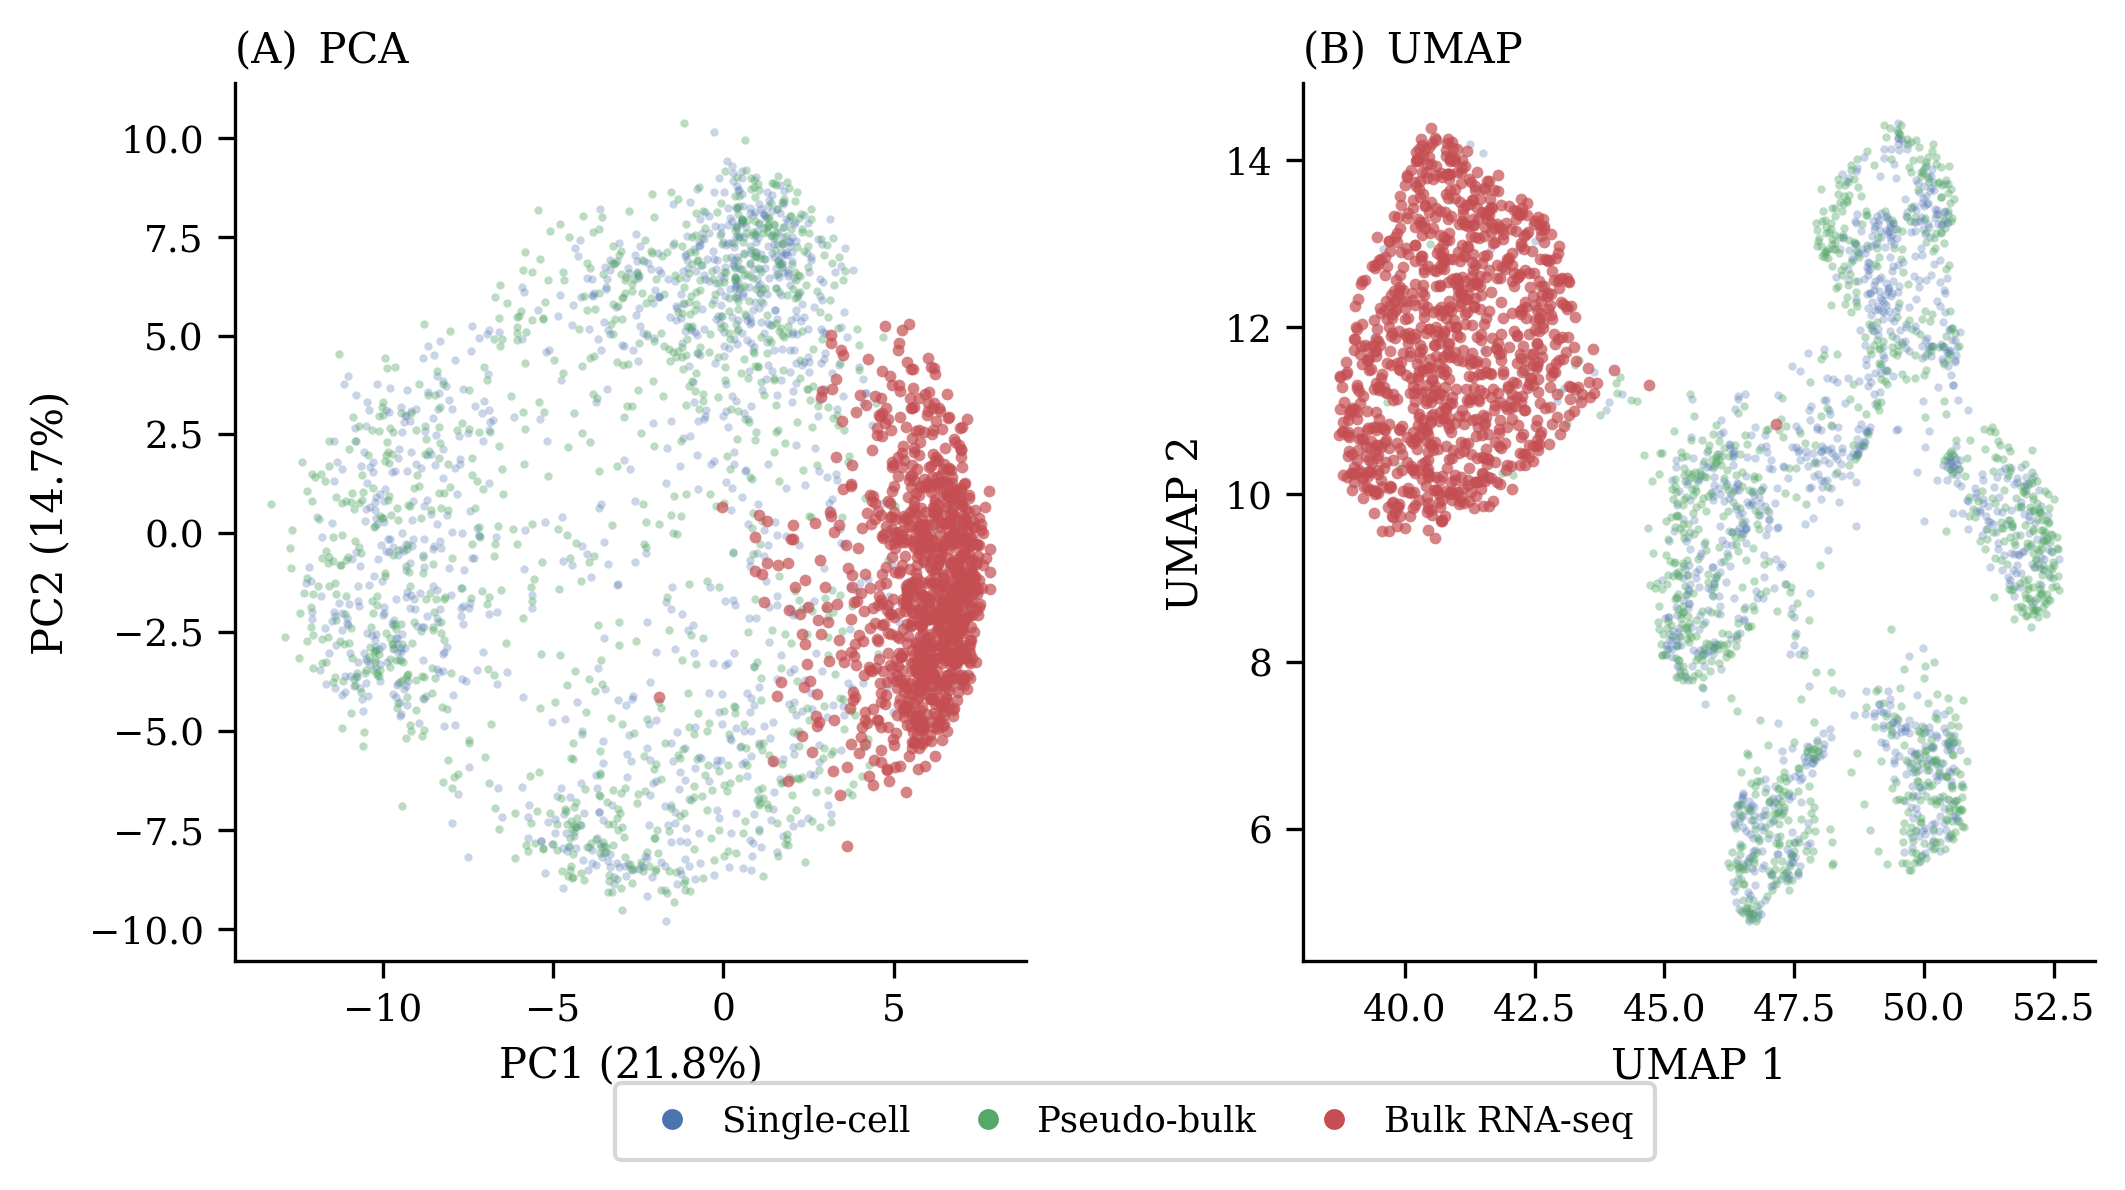

In [14]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D

try:
    import umap
    HAS_UMAP = True
except ImportError:
    print("umap-learn not found -- skipping UMAP (pip install umap-learn)")
    HAS_UMAP = False

# ---- CONFIG ------------------------------------------------------------------
SEED = 42

# ---- LOAD --------------------------------------------------------------------
emb_pseudo_bulk = np.load('emb_pseudo_bulk.npy')
emb_sc          = np.load('emb_sc.npy')
emb_bulk        = np.load('emb_bulk.npy')

print(f"pseudo-bulk : {emb_pseudo_bulk.shape}")
print(f"single-cell : {emb_sc.shape}")
print(f"bulk TCGA   : {emb_bulk.shape}")

# ---- COMBINED MATRIX ---------------------------------------------------------
all_X = np.vstack([emb_sc, emb_pseudo_bulk, emb_bulk])
labels = (
    ['Single-cell']  * len(emb_sc) +
    ['Pseudo-bulk']  * len(emb_pseudo_bulk) +
    ['Bulk RNA-seq'] * len(emb_bulk)
)

# ---- PCA ---------------------------------------------------------------------
print("Running PCA...")
pca        = PCA(n_components=2, random_state=SEED)
pca_coords = pca.fit_transform(all_X)
var_exp    = pca.explained_variance_ratio_

# ---- UMAP --------------------------------------------------------------------
if HAS_UMAP:
    print("Running UMAP...")
    reducer     = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=30, min_dist=0.3)
    umap_coords = reducer.fit_transform(all_X)

# ---- STYLE -------------------------------------------------------------------
plt.rcParams.update({
    'font.family':    'serif',
    'font.serif':     ['Times New Roman', 'DejaVu Serif'],
    'font.size':      9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'axes.linewidth': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'figure.dpi':     300,
    'savefig.dpi':    300,
    'pdf.fonttype':   42,
    'ps.fonttype':    42,
})

COLORS = {
    'Single-cell':  '#4C72B0',
    'Pseudo-bulk':  '#55A868',
    'Bulk RNA-seq': '#C44E52',
}
ALPHA = {'Single-cell': 0.3, 'Pseudo-bulk': 0.4, 'Bulk RNA-seq': 0.7}
SIZE  = {'Single-cell': 4,   'Pseudo-bulk': 4,   'Bulk RNA-seq': 8}
ORDER = ['Single-cell', 'Pseudo-bulk', 'Bulk RNA-seq']  # bulk on top

def scatter_groups(ax, coords):
    for label in ORDER:
        idx = [i for i, l in enumerate(labels) if l == label]
        ax.scatter(coords[idx, 0], coords[idx, 1],
                   c=COLORS[label], s=SIZE[label], alpha=ALPHA[label],
                   linewidths=0, rasterized=True, label=label)
    ax.spines[['top', 'right']].set_visible(False)

n_panels = 2 if HAS_UMAP else 1
fig, axes = plt.subplots(1, n_panels, figsize=(4.0 * n_panels, 3.8),
                         gridspec_kw={'wspace': 0.35})
if n_panels == 1:
    axes = [axes]

# Panel A: PCA
scatter_groups(axes[0], pca_coords)
axes[0].set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)')
axes[0].set_title('(A)\u2002PCA', pad=5, loc='left')

# Panel B: UMAP
if HAS_UMAP:
    scatter_groups(axes[1], umap_coords)
    axes[1].set_xlabel('UMAP 1')
    axes[1].set_ylabel('UMAP 2')
    axes[1].set_title('(B)\u2002UMAP', pad=5, loc='left')

# ---- LEGEND ------------------------------------------------------------------
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLORS[l],
           markersize=6, label=l)
    for l in ORDER
]
fig.legend(handles=legend_handles, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.08), frameon=True,
           handletextpad=0.4, columnspacing=1.2, borderpad=0.6, fontsize=8.5)

plt.savefig('embeddings_pca_umap.pdf', bbox_inches='tight')
plt.savefig('embeddings_pca_umap.png', bbox_inches='tight')
print("Saved: embeddings_pca_umap.pdf  /  embeddings_pca_umap.png")
plt.show()

## RAW SCGPT EMBEDDINGS

In [16]:
import torch
import numpy as np
from torch.utils.data import DataLoader
from tqdm import tqdm

# ---- CONFIG ------------------------------------------------------------------
model_path = '../papers/scgpt/save/whole_human'
check_path = 'checkpoints/best_scgpt_lr_0.00001_bs_128_ep_20_drop_0.5_seqlen_3000_hiddims_512_512.pt'
device     = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 128
SEED       = 42

# ---- MODEL -------------------------------------------------------------------
print("Loading scGPT model...")
scgpt_model, vocab = get_scgpt_model(model_path, device=device)
scgpt_model.eval()

model, _ = load_trained_model(check_path, scgpt_model, device=device)

# ---- DATASETS & LOADERS ------------------------------------------------------
adata_dataset = bulkDataset(adata, vocab)
sc_dataset    = scDataset(adata, vocab)
data_dataset  = predictionDataset(data, vocab)

def subset_dataset(dataset, n):
    n   = min(n, len(dataset))
    idx = rng.choice(len(dataset), n, replace=False).tolist()
    return torch.utils.data.Subset(dataset, idx)
 
# ---- DATASETS & LOADERS ------------------------------------------------------
adata_dataset = subset_dataset(bulkDataset(adata, vocab),        1000)
sc_dataset    = subset_dataset(scDataset(adata, vocab),          1000)
data_dataset  = subset_dataset(predictionDataset(data, vocab),   1000)
 

adata_loader = DataLoader(adata_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn,
                          shuffle=False, num_workers=0)
sc_loader    = DataLoader(sc_dataset,    batch_size=BATCH_SIZE, collate_fn=collate_fn,
                          shuffle=False, num_workers=0)
data_loader  = DataLoader(data_dataset,  batch_size=BATCH_SIZE, collate_fn=collate_fn,
                          shuffle=False, num_workers=0)

# ---- EMBEDDING EXTRACTION ----------------------------------------------------
def extract_embeddings(loader, name):
    embeddings = []
    print(f"Extracting embeddings: {name}...")
    with torch.no_grad():
        for src, values, mask, ids, _ in tqdm(loader, desc=name):
            src, values, mask = src.to(device), values.to(device), mask.to(device)
            output = scgpt_model(src, values, mask)
            emb    = output["cell_emb"]
            embeddings.append(emb.cpu().numpy())
    return np.vstack(embeddings)

emb_pseudo_bulk_scgpt = extract_embeddings(adata_loader, "pseudo-bulk (adata)")
emb_sc_scgpt          = extract_embeddings(sc_loader,    "single-cell (sc)")
emb_bulk_scgpt        = extract_embeddings(data_loader,  "bulk TCGA")

print(f"\nEmbedding shapes:")
print(f"  pseudo-bulk : {emb_pseudo_bulk_scgpt.shape}")
print(f"  single-cell : {emb_sc_scgpt.shape}")
print(f"  bulk TCGA   : {emb_bulk_scgpt.shape}")

# ---- SAVE --------------------------------------------------------------------
np.save('emb_pseudo_bulk_scgpt.npy', emb_pseudo_bulk_scgpt)
np.save('emb_sc_scgpt.npy',          emb_sc_scgpt)
np.save('emb_bulk_scgpt.npy',        emb_bulk_scgpt)
print("\nSaved: emb_pseudo_bulk_scgpt.npy  emb_sc_scgpt.npy  emb_bulk_scgpt.npy")


Loading scGPT model...


/storage/scratch/2370352/my-research/papers/scgpt/scgpt/model/model.py:77: UserWarning: flash-attn is not installed, using pytorch transformer instead. Set use_fast_transformer=False to avoid this warning. Installing flash-attn is highly recommended.
  warnings.warn(


Extracting embeddings: pseudo-bulk (adata)...


pseudo-bulk (adata): 100%|██████████| 8/8 [00:33<00:00,  4.18s/it]


Extracting embeddings: single-cell (sc)...


single-cell (sc): 100%|██████████| 8/8 [00:22<00:00,  2.82s/it]


Extracting embeddings: bulk TCGA...


bulk TCGA: 100%|██████████| 8/8 [00:45<00:00,  5.71s/it]


Embedding shapes:
  pseudo-bulk : (1000, 512)
  single-cell : (1000, 512)
  bulk TCGA   : (1000, 512)

Saved: emb_pseudo_bulk_scgpt.npy  emb_sc_scgpt.npy  emb_bulk_scgpt.npy


pseudo-bulk : (1000, 512)
single-cell : (1000, 512)
bulk TCGA   : (1000, 512)
Running PCA...
Running UMAP...


/scratch/2370352/conda/envs/scgpt/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved: embeddings_pca_umap.pdf  /  embeddings_pca_umap.png


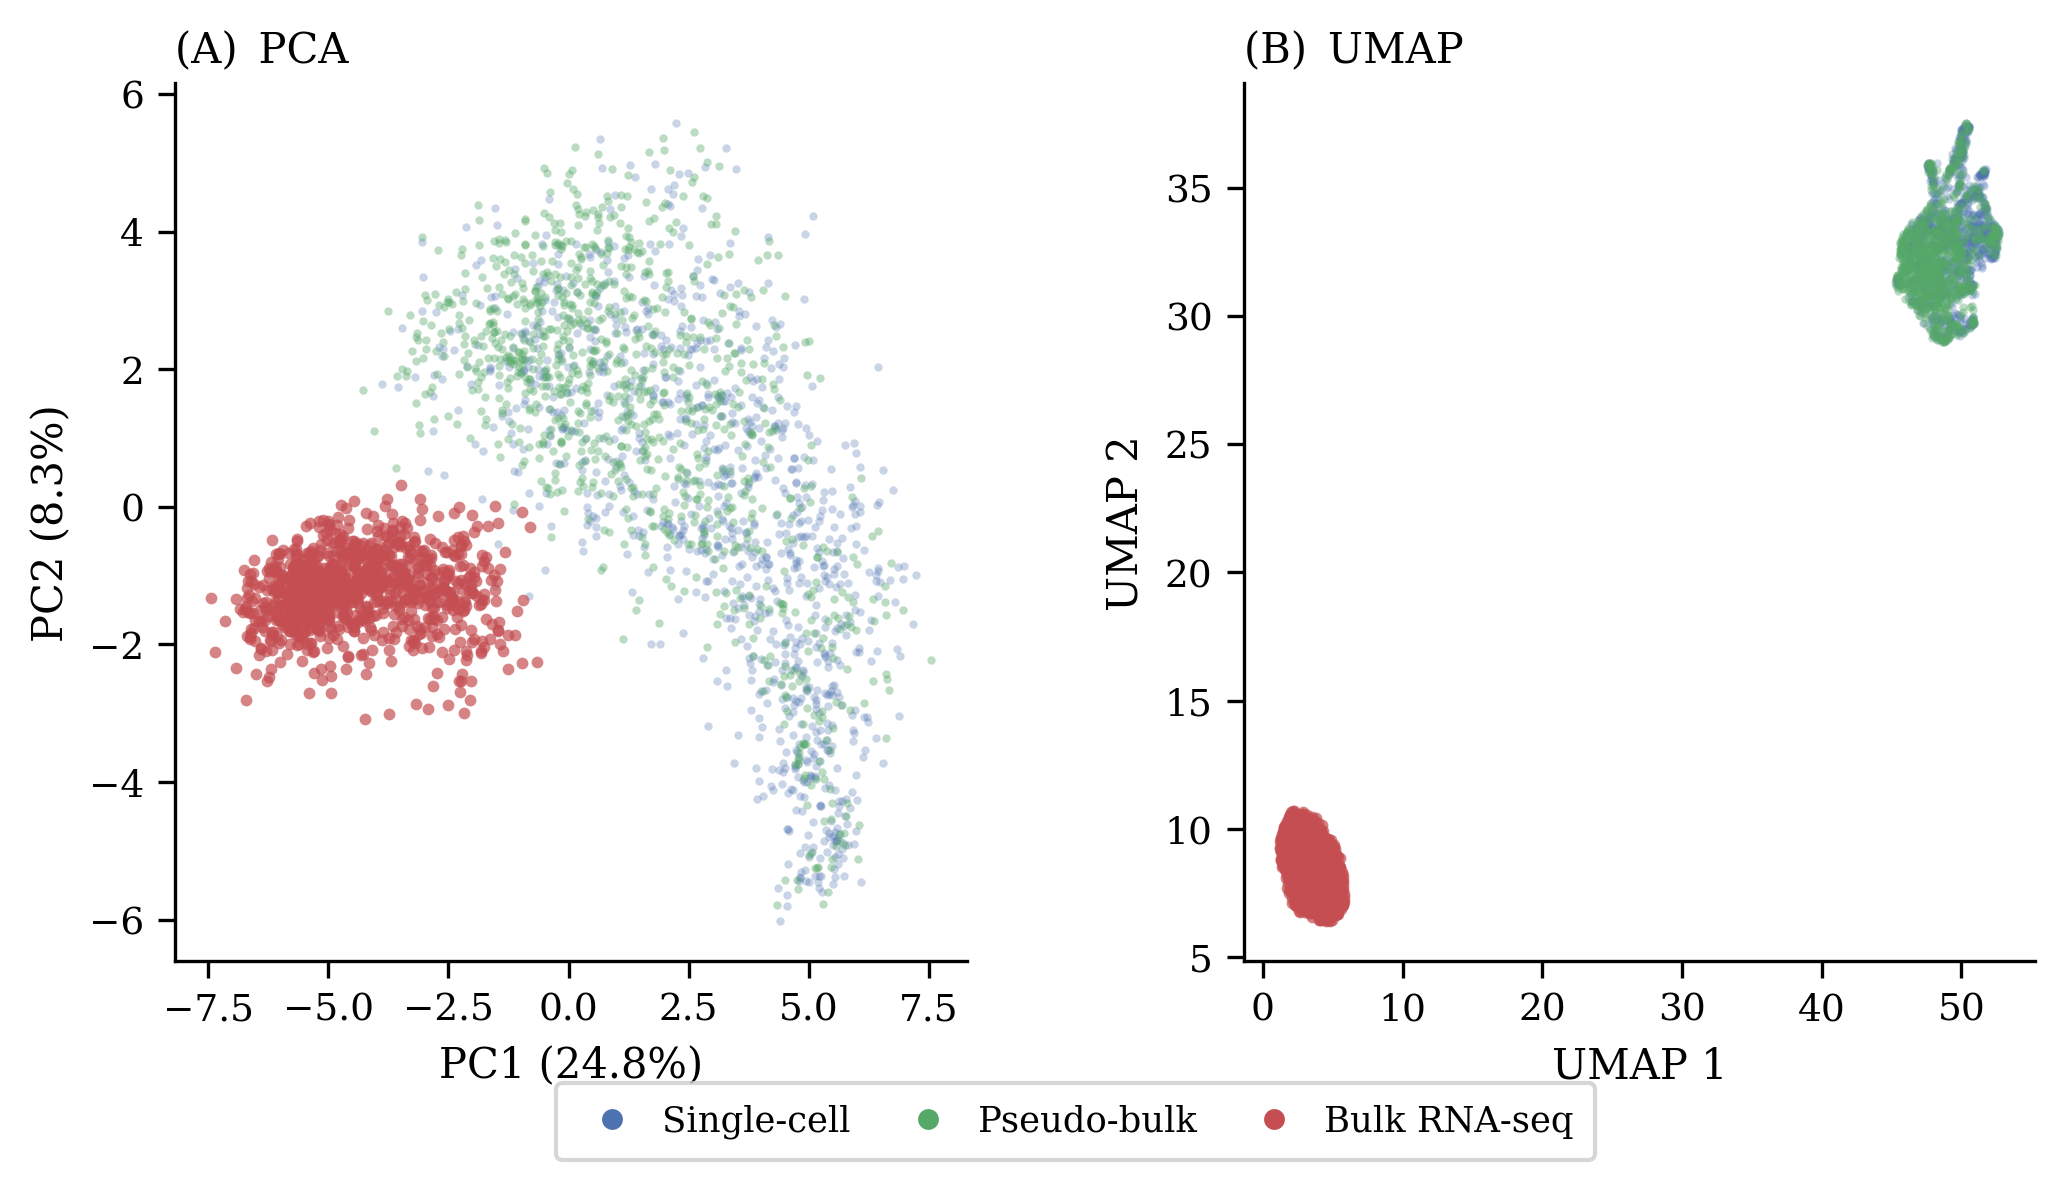

In [17]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D

try:
    import umap
    HAS_UMAP = True
except ImportError:
    print("umap-learn not found -- skipping UMAP (pip install umap-learn)")
    HAS_UMAP = False

# ---- CONFIG ------------------------------------------------------------------
SEED = 42

# ---- LOAD --------------------------------------------------------------------
emb_pseudo_bulk = np.load('emb_pseudo_bulk_scgpt.npy')
emb_sc          = np.load('emb_sc_scgpt.npy')
emb_bulk        = np.load('emb_bulk_scgpt.npy')

print(f"pseudo-bulk : {emb_pseudo_bulk.shape}")
print(f"single-cell : {emb_sc.shape}")
print(f"bulk TCGA   : {emb_bulk.shape}")

# ---- COMBINED MATRIX ---------------------------------------------------------
all_X = np.vstack([emb_sc, emb_pseudo_bulk, emb_bulk])
labels = (
    ['Single-cell']  * len(emb_sc) +
    ['Pseudo-bulk']  * len(emb_pseudo_bulk) +
    ['Bulk RNA-seq'] * len(emb_bulk)
)

# ---- PCA ---------------------------------------------------------------------
print("Running PCA...")
pca        = PCA(n_components=2, random_state=SEED)
pca_coords = pca.fit_transform(all_X)
var_exp    = pca.explained_variance_ratio_

# ---- UMAP --------------------------------------------------------------------
if HAS_UMAP:
    print("Running UMAP...")
    reducer     = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=30, min_dist=0.3)
    umap_coords = reducer.fit_transform(all_X)

# ---- STYLE -------------------------------------------------------------------
plt.rcParams.update({
    'font.family':    'serif',
    'font.serif':     ['Times New Roman', 'DejaVu Serif'],
    'font.size':      9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'axes.linewidth': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'figure.dpi':     300,
    'savefig.dpi':    300,
    'pdf.fonttype':   42,
    'ps.fonttype':    42,
})

COLORS = {
    'Single-cell':  '#4C72B0',
    'Pseudo-bulk':  '#55A868',
    'Bulk RNA-seq': '#C44E52',
}
ALPHA = {'Single-cell': 0.3, 'Pseudo-bulk': 0.4, 'Bulk RNA-seq': 0.7}
SIZE  = {'Single-cell': 4,   'Pseudo-bulk': 4,   'Bulk RNA-seq': 8}
ORDER = ['Single-cell', 'Pseudo-bulk', 'Bulk RNA-seq']  # bulk on top

def scatter_groups(ax, coords):
    for label in ORDER:
        idx = [i for i, l in enumerate(labels) if l == label]
        ax.scatter(coords[idx, 0], coords[idx, 1],
                   c=COLORS[label], s=SIZE[label], alpha=ALPHA[label],
                   linewidths=0, rasterized=True, label=label)
    ax.spines[['top', 'right']].set_visible(False)

n_panels = 2 if HAS_UMAP else 1
fig, axes = plt.subplots(1, n_panels, figsize=(4.0 * n_panels, 3.8),
                         gridspec_kw={'wspace': 0.35})
if n_panels == 1:
    axes = [axes]

# Panel A: PCA
scatter_groups(axes[0], pca_coords)
axes[0].set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)')
axes[0].set_title('(A)\u2002PCA', pad=5, loc='left')

# Panel B: UMAP
if HAS_UMAP:
    scatter_groups(axes[1], umap_coords)
    axes[1].set_xlabel('UMAP 1')
    axes[1].set_ylabel('UMAP 2')
    axes[1].set_title('(B)\u2002UMAP', pad=5, loc='left')

# ---- LEGEND ------------------------------------------------------------------
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLORS[l],
           markersize=6, label=l)
    for l in ORDER
]
fig.legend(handles=legend_handles, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.08), frameon=True,
           handletextpad=0.4, columnspacing=1.2, borderpad=0.6, fontsize=8.5)

plt.savefig('embeddings_pca_umap.pdf', bbox_inches='tight')
plt.savefig('embeddings_pca_umap.png', bbox_inches='tight')
print("Saved: embeddings_pca_umap.pdf  /  embeddings_pca_umap.png")
plt.show()

In [28]:
batch_sc

(tensor([[30807,  2921, 21193,  ...,     0,     0,     0],
         [12241, 30807, 10170,  ...,     0,     0,     0],
         [10954, 32403,  3936,  ...,     0,     0,     0],
         ...,
         [10954, 33823,  2954,  ...,     0,     0,     0],
         [12241, 33817, 33823,  ...,     0,     0,     0],
         [17868, 33817, 33823,  ...,     0,     0,     0]]),
 tensor([[ 4., 38., 33.,  ...,  0.,  0.,  0.],
         [17.,  7., 17.,  ...,  0.,  0.,  0.],
         [26., 23.,  1.,  ...,  0.,  0.,  0.],
         ...,
         [27., 45.,  9.,  ...,  0.,  0.,  0.],
         [16., 10., 46.,  ...,  0.,  0.,  0.],
         [32., 49., 49.,  ...,  0.,  0.,  0.]]),
 tensor([[False, False, False,  ...,  True,  True,  True],
         [False, False, False,  ...,  True,  True,  True],
         [False, False, False,  ...,  True,  True,  True],
         ...,
         [False, False, False,  ...,  True,  True,  True],
         [False, False, False,  ...,  True,  True,  True],
         [False, False,

Fetching batches...

                         pseudo-bulk     single-cell            bulk
--------------------------------------------------------------------
src shape                (128, 2000)     (128, 2000)     (128, 2000)
values shape             (128, 2000)     (128, 2000)     (128, 2000)
src dtype                torch.int64     torch.int64     torch.int64
values dtype           torch.float32   torch.float32   torch.float32

                         pseudo-bulk     single-cell            bulk
--------------------------------------------------------------------
values min                     0.000           0.000           1.000
values max                    50.000          50.000          50.000
values mean                   23.748          17.924          25.001
values std                    15.000          16.623          14.148
unique bins                       51              51              50
unique genes (src)             14233           13998            7582

Gene set Ja

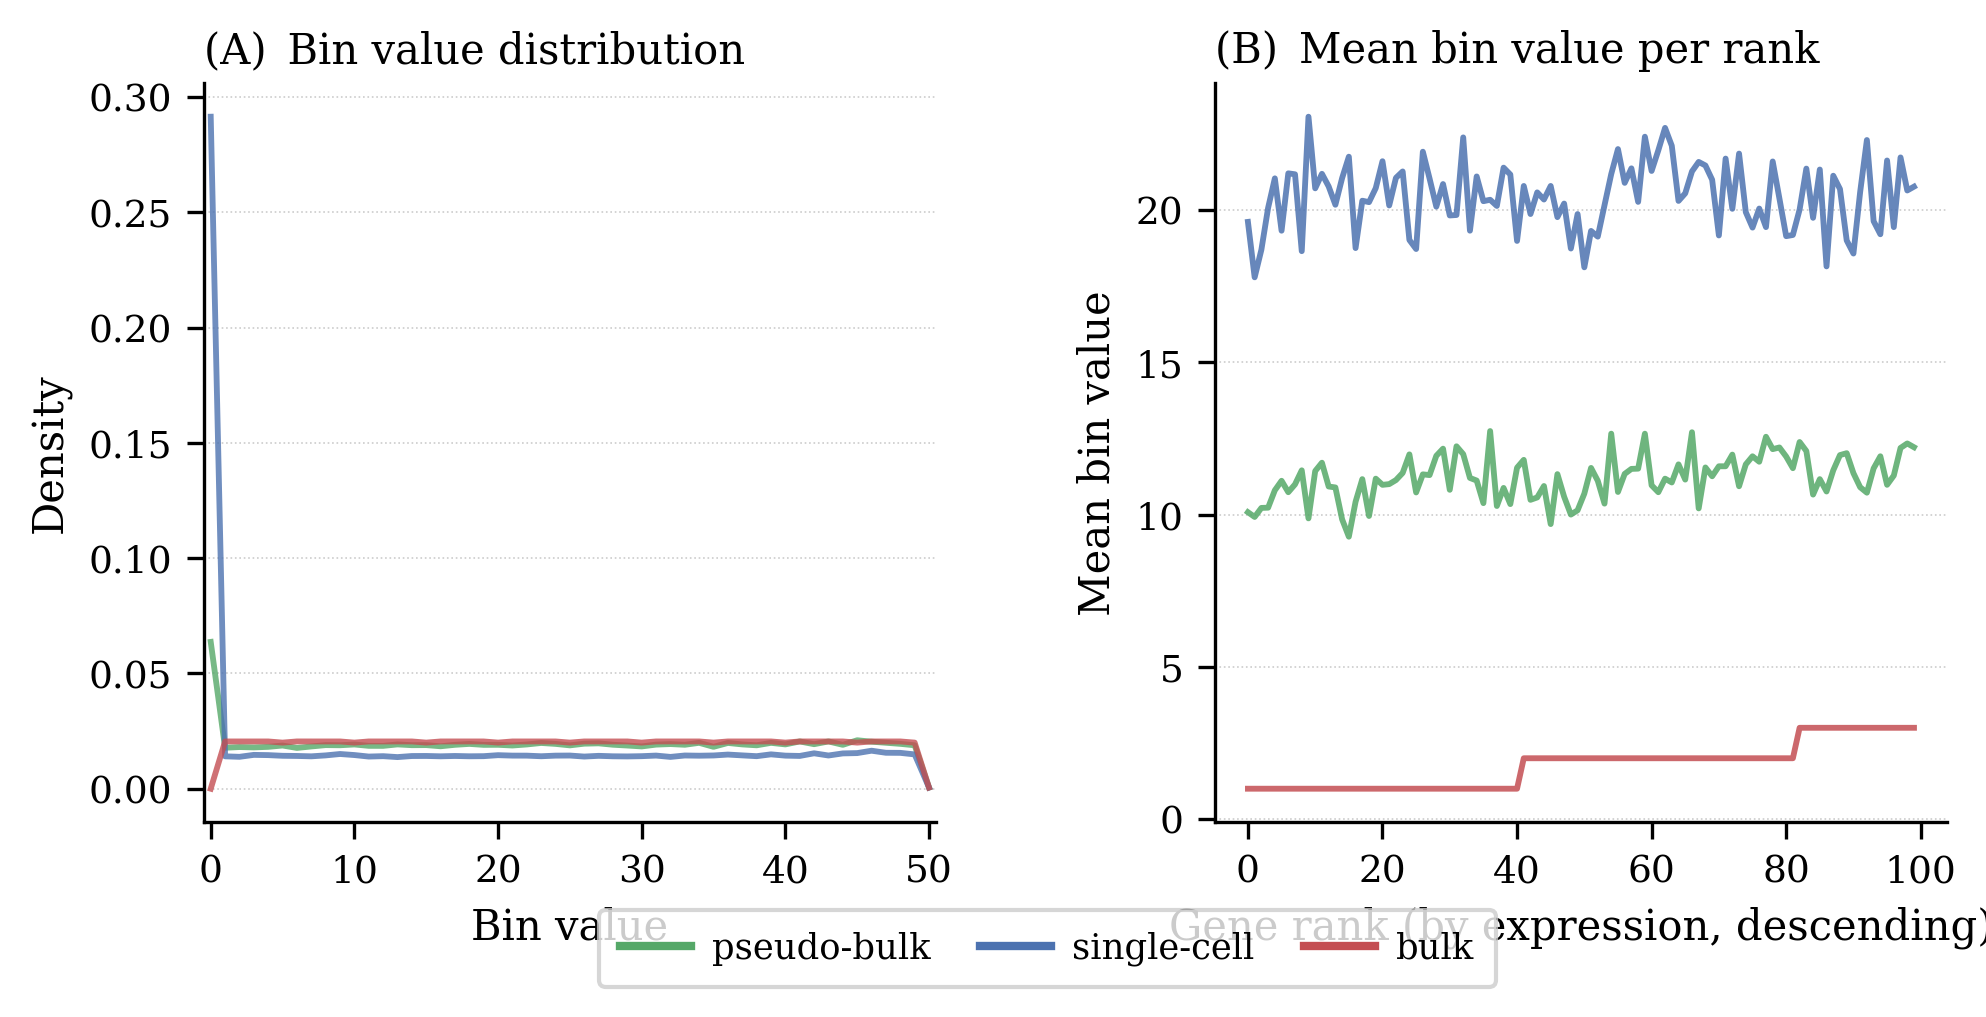

In [32]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D

# ---- GRAB ONE BATCH FROM EACH LOADER ----------------------------------------
def get_batch(loader):
    return next(iter(loader))

print("Fetching batches...")
batch_pseudo = get_batch(adata_loader)
batch_sc     = get_batch(sc_loader)
batch_bulk   = get_batch(data_loader)

src_pseudo, val_pseudo, mask_pseudo, ids_pseudo, _ = batch_pseudo
src_sc,     val_sc,     mask_sc,     ids_sc,     _ = batch_sc
src_bulk,   val_bulk,   mask_bulk,   ids_bulk,   _ = batch_bulk

print(f"\n{'':20s} {'pseudo-bulk':>15} {'single-cell':>15} {'bulk':>15}")
print("-" * 68)
print(f"{'src shape':20s} {str(tuple(src_pseudo.shape)):>15} {str(tuple(src_sc.shape)):>15} {str(tuple(src_bulk.shape)):>15}")
print(f"{'values shape':20s} {str(tuple(val_pseudo.shape)):>15} {str(tuple(val_sc.shape)):>15} {str(tuple(val_bulk.shape)):>15}")
print(f"{'src dtype':20s} {str(src_pseudo.dtype):>15} {str(src_sc.dtype):>15} {str(src_bulk.dtype):>15}")
print(f"{'values dtype':20s} {str(val_pseudo.dtype):>15} {str(val_sc.dtype):>15} {str(val_bulk.dtype):>15}")

# flatten values (ignore padding via mask)
def masked_vals(values, mask):
    # mask is all False (no padding) -- just use all values
    return values.float().numpy().flatten()

vp = masked_vals(val_pseudo, mask_pseudo)
vs = masked_vals(val_sc,     mask_sc)
vb = masked_vals(val_bulk,   mask_bulk)

print(f"\n{'':20s} {'pseudo-bulk':>15} {'single-cell':>15} {'bulk':>15}")
print("-" * 68)
print(f"{'values min':20s} {vp.min():>15.3f} {vs.min():>15.3f} {vb.min():>15.3f}")
print(f"{'values max':20s} {vp.max():>15.3f} {vs.max():>15.3f} {vb.max():>15.3f}")
print(f"{'values mean':20s} {vp.mean():>15.3f} {vs.mean():>15.3f} {vb.mean():>15.3f}")
print(f"{'values std':20s} {vp.std():>15.3f} {vs.std():>15.3f} {vb.std():>15.3f}")
print(f"{'unique bins':20s} {len(np.unique(vp)):>15} {len(np.unique(vs)):>15} {len(np.unique(vb)):>15}")
print(f"{'unique genes (src)':20s} {src_pseudo.unique().numel():>15} {src_sc.unique().numel():>15} {src_bulk.unique().numel():>15}")

# gene overlap across datasets (excluding padding token if any)
def get_gene_set(src, mask):
    return set(src.numpy().flatten().tolist())

genes_pseudo = get_gene_set(src_pseudo, mask_pseudo)
genes_sc     = get_gene_set(src_sc,     mask_sc)
genes_bulk   = get_gene_set(src_bulk,   mask_bulk)

j_ps_b = len(genes_pseudo & genes_bulk)  / len(genes_pseudo | genes_bulk)
j_sc_b = len(genes_sc     & genes_bulk)  / len(genes_sc     | genes_bulk)
j_ps_s = len(genes_pseudo & genes_sc)    / len(genes_pseudo | genes_sc)

print(f"\nGene set Jaccard (batch-level):")
print(f"  pseudo-bulk vs bulk : {j_ps_b:.3f}")
print(f"  single-cell vs bulk : {j_sc_b:.3f}")
print(f"  pseudo-bulk vs sc   : {j_ps_s:.3f}")

# ---- PLOTS -------------------------------------------------------------------
plt.rcParams.update({
    'font.family':    'serif',
    'font.serif':     ['Times New Roman', 'DejaVu Serif'],
    'font.size':      9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'axes.linewidth': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'figure.dpi':     300,
    'savefig.dpi':    300,
    'pdf.fonttype':   42,
    'ps.fonttype':    42,
})

COLORS = {
    'pseudo-bulk': '#55A868',
    'single-cell': '#4C72B0',
    'bulk':        '#C44E52',
}

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.2), gridspec_kw={'wspace': 0.38})

# Panel A: bin value distribution
ax = axes[0]
bin_min = int(min(vp.min(), vs.min(), vb.min()))
bin_max = int(max(vp.max(), vs.max(), vb.max()))
bins = np.arange(bin_min, bin_max + 2) - 0.5
for vals, label in [(vp, 'pseudo-bulk'), (vs, 'single-cell'), (vb, 'bulk')]:
    counts, edges = np.histogram(vals, bins=bins, density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    ax.plot(centers, counts, lw=1.4, color=COLORS[label], label=label, alpha=0.8)
ax.set_xlabel('Bin value')
ax.set_ylabel('Density')
ax.set_xlim(bin_min - 0.5, bin_max + 0.5)
ax.set_title('(A)\u2002Bin value distribution', pad=5, loc='left')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, axis='y', lw=0.4, ls=':', color='0.8')

# Panel B: mean bin per rank (averaged over batch)
ax = axes[1]
N_POS = 100
for val, label in [
    (val_pseudo, 'pseudo-bulk'),
    (val_sc,     'single-cell'),
    (val_bulk,   'bulk'),
]:
    # genes are sorted by expression descending, so position = rank
    mean_per_pos = val.float().mean(dim=0).numpy()
    ax.plot(range(N_POS), mean_per_pos[:N_POS],
            lw=1.4, color=COLORS[label], label=label, alpha=0.85)
ax.set_xlabel('Gene rank (by expression, descending)')
ax.set_ylabel('Mean bin value')
ax.set_title('(B)\u2002Mean bin value per rank', pad=5, loc='left')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, axis='y', lw=0.4, ls=':', color='0.8')

# shared legend
handles = [Line2D([0], [0], color=COLORS[l], lw=2, label=l)
           for l in ['pseudo-bulk', 'single-cell', 'bulk']]
fig.legend(handles=handles, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.08), frameon=True,
           handletextpad=0.6, columnspacing=1.4, borderpad=0.6, fontsize=8.5)

plt.savefig('batch_diagnostics.pdf', bbox_inches='tight')
plt.savefig('batch_diagnostics.png', bbox_inches='tight')
print("\nSaved: batch_diagnostics.pdf  /  batch_diagnostics.png")
plt.show()